# Scatter-Plot Matrix for Correlation Analysis

This notebook performs correlation analysis of discretized attribute pairs using scatter-plot matrices.

## Dataset: Baton Rouge Traffic Crash Incidents (preprocessing-1.csv)

The dataset contains 45,385 traffic crash incidents with 25 attributes including:
- Categorical attributes (discretized): district, zone, crash_occurred_on, type_of_roadway, road_surface, weather_condition, lighting_condition, vehicle_alignment, relation_to_roadway, manner_of_collision, primary_factor, secondary_factor, day_of_week
- Binary attributes: injury, fatality, hit_and_run, pedestrian_involved, train_involved, intersection
- Numerical attributes: total_vehicles, latitude, longitude, crash_month, crash_year


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [2]:
# Load the dataset
df = pd.read_csv('preprocessing-1.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)


Dataset shape: (45385, 25)

Columns: ['crash_date', 'district', 'zone', 'crash_occurred_on', 'type_of_roadway', 'road_surface', 'weather_condition', 'lighting_condition', 'injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 'train_involved', 'intersection', 'total_vehicles', 'vehicle_alignment', 'relation_to_roadway', 'manner_of_collision', 'primary_factor', 'secondary_factor', 'latitude', 'longitude', 'day_of_week', 'crash_month', 'crash_year']

Data types:
crash_date              object
district                 int64
zone                    object
crash_occurred_on       object
type_of_roadway         object
road_surface            object
weather_condition       object
lighting_condition      object
injury                   int64
fatality                 int64
hit_and_run              int64
pedestrian_involved      int64
train_involved           int64
intersection              bool
total_vehicles           int64
vehicle_alignment       object
relation_to_roadway     object
man

In [3]:
# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45385 entries, 0 to 45384
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   crash_date           45385 non-null  object 
 1   district             45385 non-null  int64  
 2   zone                 45385 non-null  object 
 3   crash_occurred_on    45385 non-null  object 
 4   type_of_roadway      45385 non-null  object 
 5   road_surface         45385 non-null  object 
 6   weather_condition    45385 non-null  object 
 7   lighting_condition   45385 non-null  object 
 8   injury               45385 non-null  int64  
 9   fatality             45385 non-null  int64  
 10  hit_and_run          45385 non-null  int64  
 11  pedestrian_involved  45385 non-null  int64  
 12  train_involved       45385 non-null  int64  
 13  intersection         45385 non-null  bool   
 14  total_vehicles       45385 non-null  int64  
 15  vehicle_alignment    4

## Data Preprocessing for Correlation Analysis

We need to encode categorical variables to numerical values for correlation analysis.


In [4]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_columns}")

# Identify binary columns
binary_columns = ['injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 'train_involved']
print(f"Binary columns: {binary_columns}")

# Convert boolean intersection column to int
df['intersection'] = df['intersection'].astype(int)
binary_columns.append('intersection')

# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {numerical_columns}")


Categorical columns: ['crash_date', 'zone', 'crash_occurred_on', 'type_of_roadway', 'road_surface', 'weather_condition', 'lighting_condition', 'vehicle_alignment', 'relation_to_roadway', 'manner_of_collision', 'primary_factor', 'secondary_factor', 'day_of_week']
Binary columns: ['injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 'train_involved']
Numerical columns: ['district', 'injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 'train_involved', 'intersection', 'total_vehicles', 'latitude', 'longitude', 'crash_month', 'crash_year']


In [5]:
# Create a copy of the dataframe for encoding
df_encoded = df.copy()

# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in categorical_columns:
    if col != 'crash_date':  # Skip date column for now
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"{col}: {len(le.classes_)} unique values")

# Convert crash_date to numerical (extract year, month, day)
df_encoded['crash_date'] = pd.to_datetime(df_encoded['crash_date'])
df_encoded['crash_day'] = df_encoded['crash_date'].dt.day
df_encoded['crash_day_of_year'] = df_encoded['crash_date'].dt.dayofyear

# Drop the original crash_date column
df_encoded = df_encoded.drop('crash_date', axis=1)

print(f"\nEncoded dataset shape: {df_encoded.shape}")
print(f"\nEncoded data types:")
print(df_encoded.dtypes)


zone: 41 unique values
crash_occurred_on: 6 unique values
type_of_roadway: 5 unique values
road_surface: 11 unique values
weather_condition: 9 unique values
lighting_condition: 8 unique values
vehicle_alignment: 4 unique values
relation_to_roadway: 11 unique values
manner_of_collision: 8 unique values
primary_factor: 12 unique values
secondary_factor: 13 unique values
day_of_week: 7 unique values

Encoded dataset shape: (45385, 26)

Encoded data types:
district                 int64
zone                     int64
crash_occurred_on        int64
type_of_roadway          int64
road_surface             int64
weather_condition        int64
lighting_condition       int64
injury                   int64
fatality                 int64
hit_and_run              int64
pedestrian_involved      int64
train_involved           int64
intersection             int64
total_vehicles           int64
vehicle_alignment        int64
relation_to_roadway      int64
manner_of_collision      int64
primary_factor  

## Correlation Analysis

Now we'll perform correlation analysis on the discretized attributes.


In [6]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

print("Correlation Matrix Shape:", correlation_matrix.shape)
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix Shape: (26, 26)

Correlation Matrix:
                     district      zone  crash_occurred_on  type_of_roadway  \
district             1.000000 -0.359511          -0.175983        -0.064037   
zone                -0.359511  1.000000           0.081783         0.100088   
crash_occurred_on   -0.175983  0.081783           1.000000         0.038597   
type_of_roadway     -0.064037  0.100088           0.038597         1.000000   
road_surface         0.003768 -0.012410           0.000694        -0.011103   
weather_condition    0.005472 -0.009351          -0.002408        -0.014756   
lighting_condition   0.022978 -0.002688           0.004126        -0.021776   
injury               0.059462 -0.030826          -0.017836        -0.061587   
fatality            -0.012105 -0.000808           0.018462         0.010867   
hit_and_run         -0.033480  0.001571           0.006509        -0.034311   
pedestrian_involved -0.020360  0.014941           0.001355         0.024051

In [7]:
# Find highly correlated pairs (absolute correlation > 0.5)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            high_corr_pairs.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values('correlation', key=abs, ascending=False)
    print("Highly Correlated Pairs (|correlation| > 0.5):")
    print(high_corr_df)
else:
    print("No pairs with correlation > 0.5 found")


Highly Correlated Pairs (|correlation| > 0.5):
           var1               var2  correlation
2   crash_month  crash_day_of_year     0.996459
1  road_surface  weather_condition     0.768524
0      district           latitude    -0.745886


## Scatter-Plot Matrix Visualization

Create scatter-plot matrices for different groups of attributes to analyze correlations.


In [8]:
# Select key attributes for scatter-plot matrix
# Focus on categorical/discretized attributes that are most relevant
key_attributes = [
    'district', 'zone', 'crash_occurred_on', 'type_of_roadway', 
    'road_surface', 'weather_condition', 'lighting_condition',
    'injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 
    'intersection', 'total_vehicles', 'vehicle_alignment', 
    'relation_to_roadway', 'manner_of_collision', 'primary_factor',
    'day_of_week', 'crash_month', 'crash_year'
]

# Filter to only include attributes that exist in the encoded dataset
key_attributes = [attr for attr in key_attributes if attr in df_encoded.columns]
print(f"Selected attributes for scatter-plot matrix: {key_attributes}")
print(f"Number of attributes: {len(key_attributes)}")


Selected attributes for scatter-plot matrix: ['district', 'zone', 'crash_occurred_on', 'type_of_roadway', 'road_surface', 'weather_condition', 'lighting_condition', 'injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 'intersection', 'total_vehicles', 'vehicle_alignment', 'relation_to_roadway', 'manner_of_collision', 'primary_factor', 'day_of_week', 'crash_month', 'crash_year']
Number of attributes: 20


<Figure size 2000x2000 with 0 Axes>

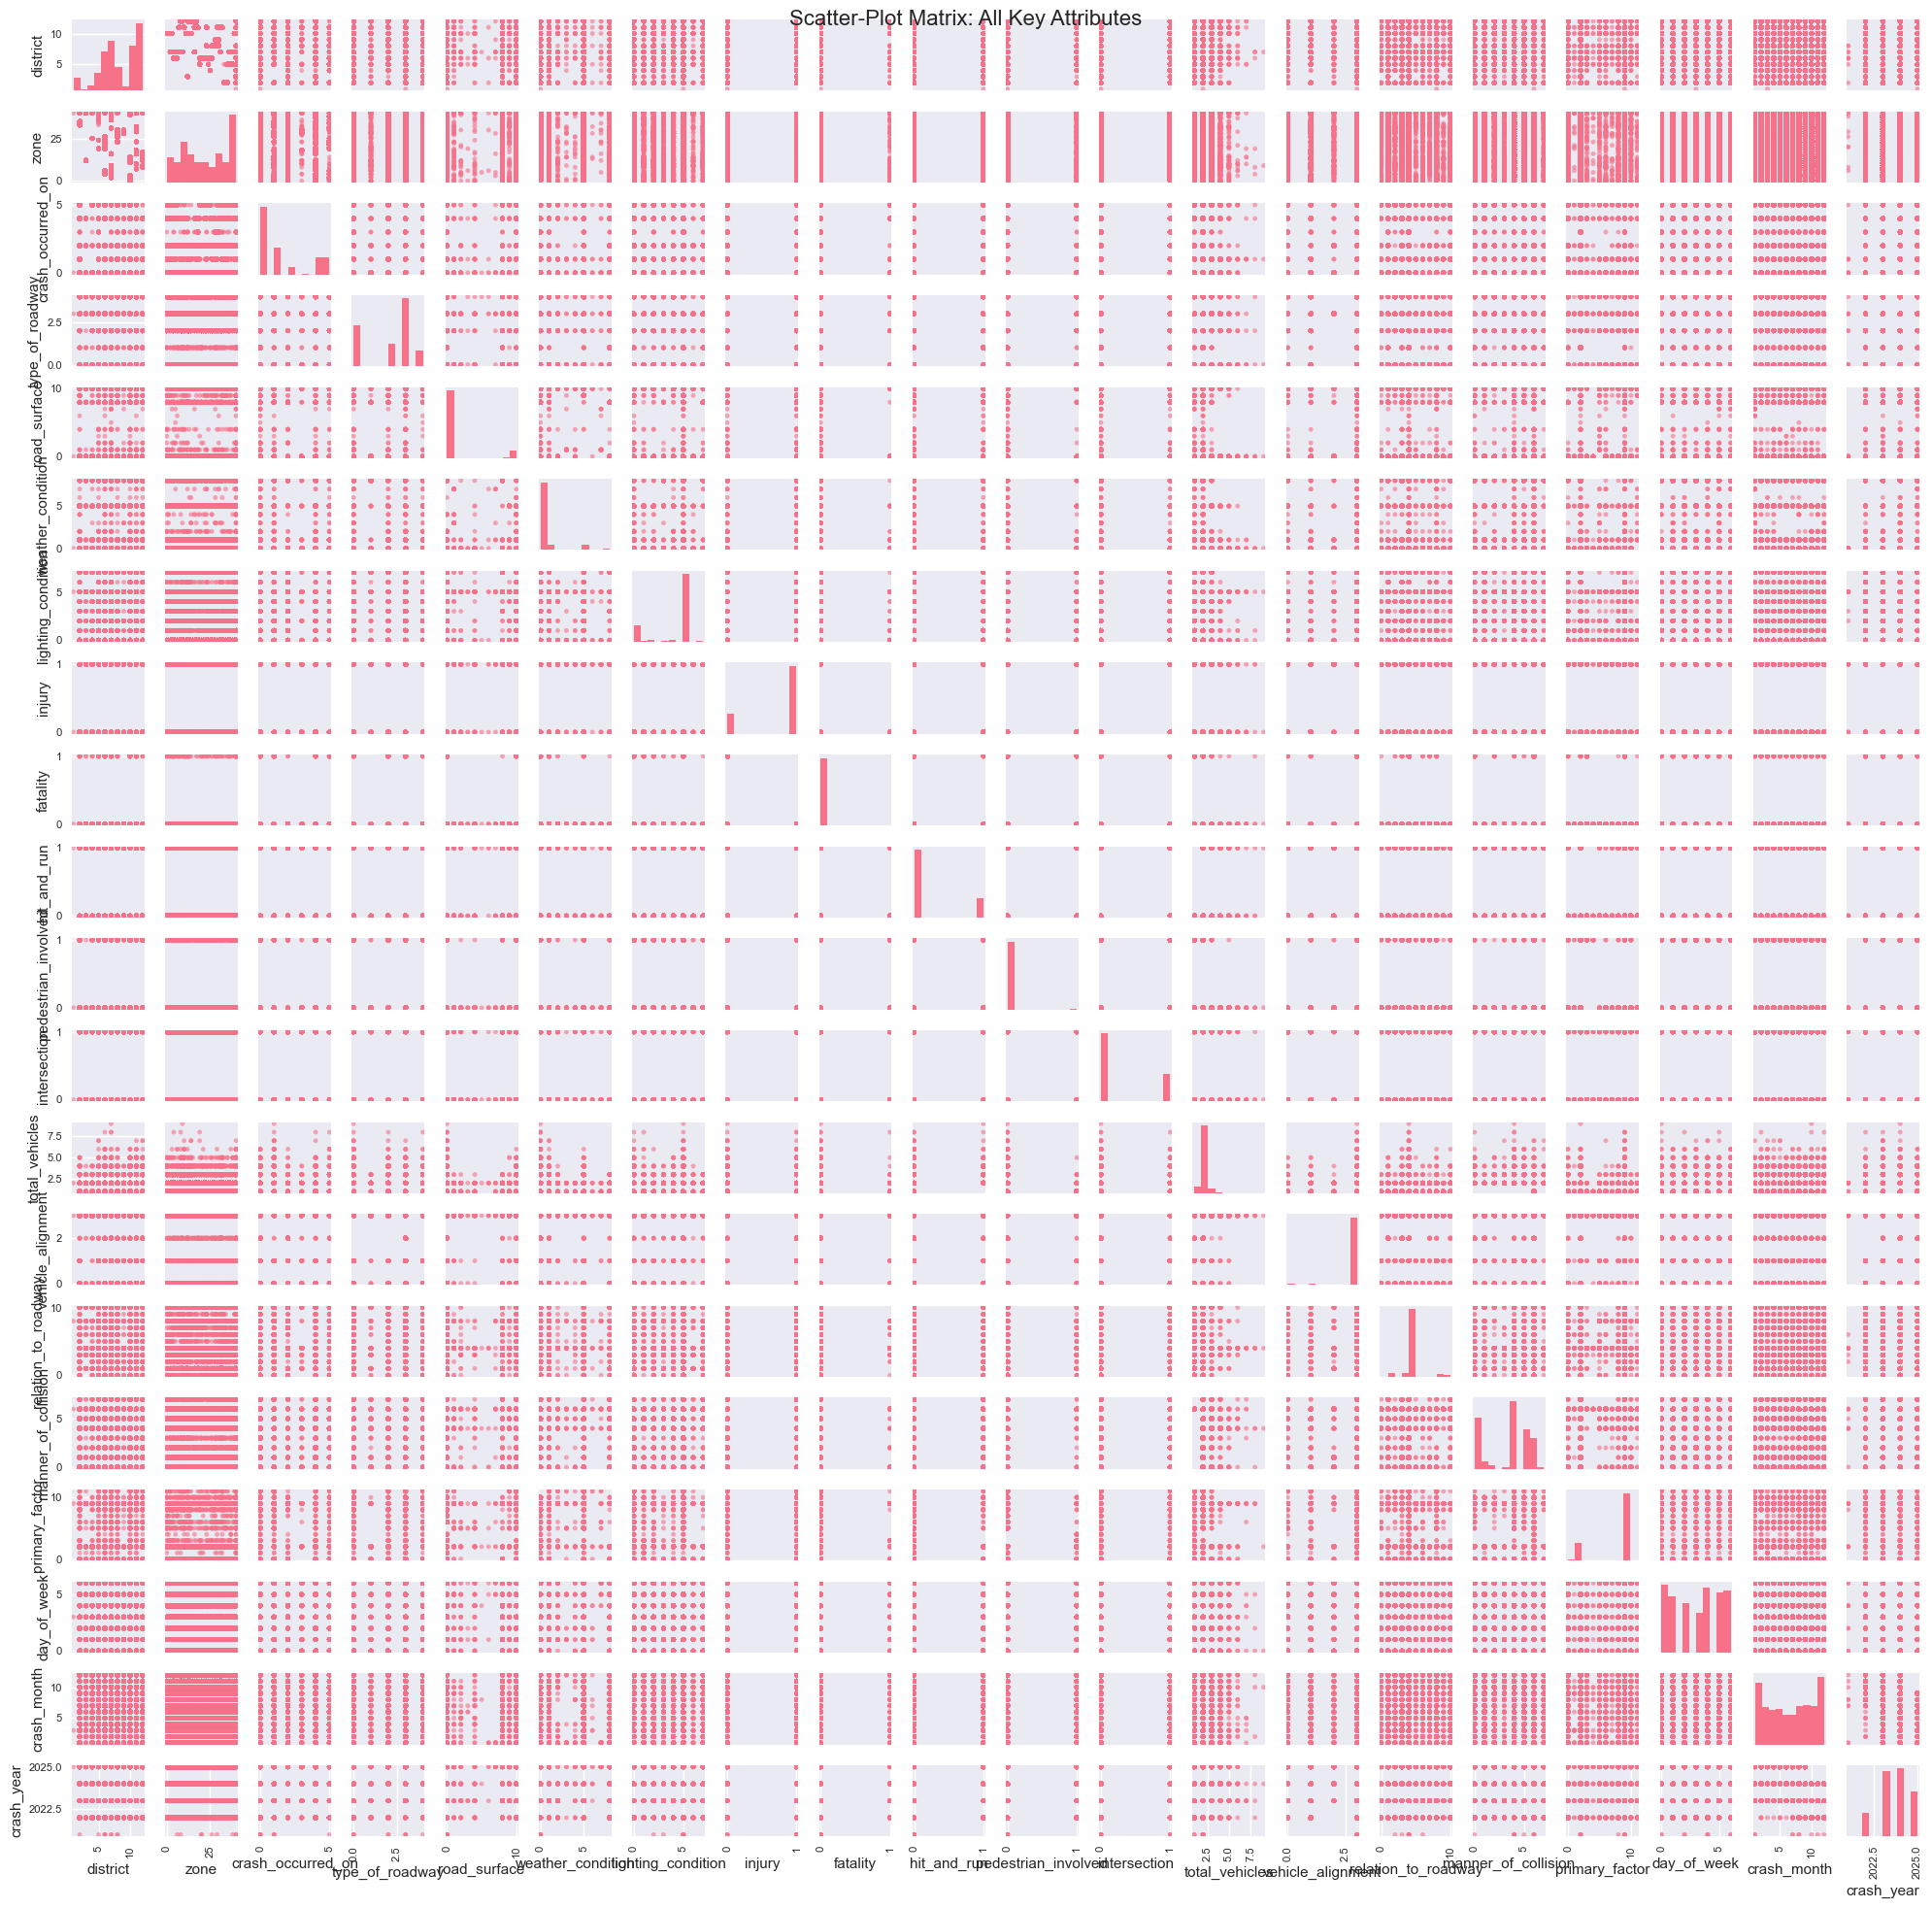

In [20]:
# Create scatter-plot matrix for all key attributes
plt.figure(figsize=(20, 20))
pd.plotting.scatter_matrix(df_encoded[key_attributes], 
                          alpha=0.6, 
                          figsize=(20, 20),
                          cmap='crest',
                          diagonal='hist')
plt.suptitle('Scatter-Plot Matrix: All Key Attributes', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


<Figure size 1500x1500 with 0 Axes>

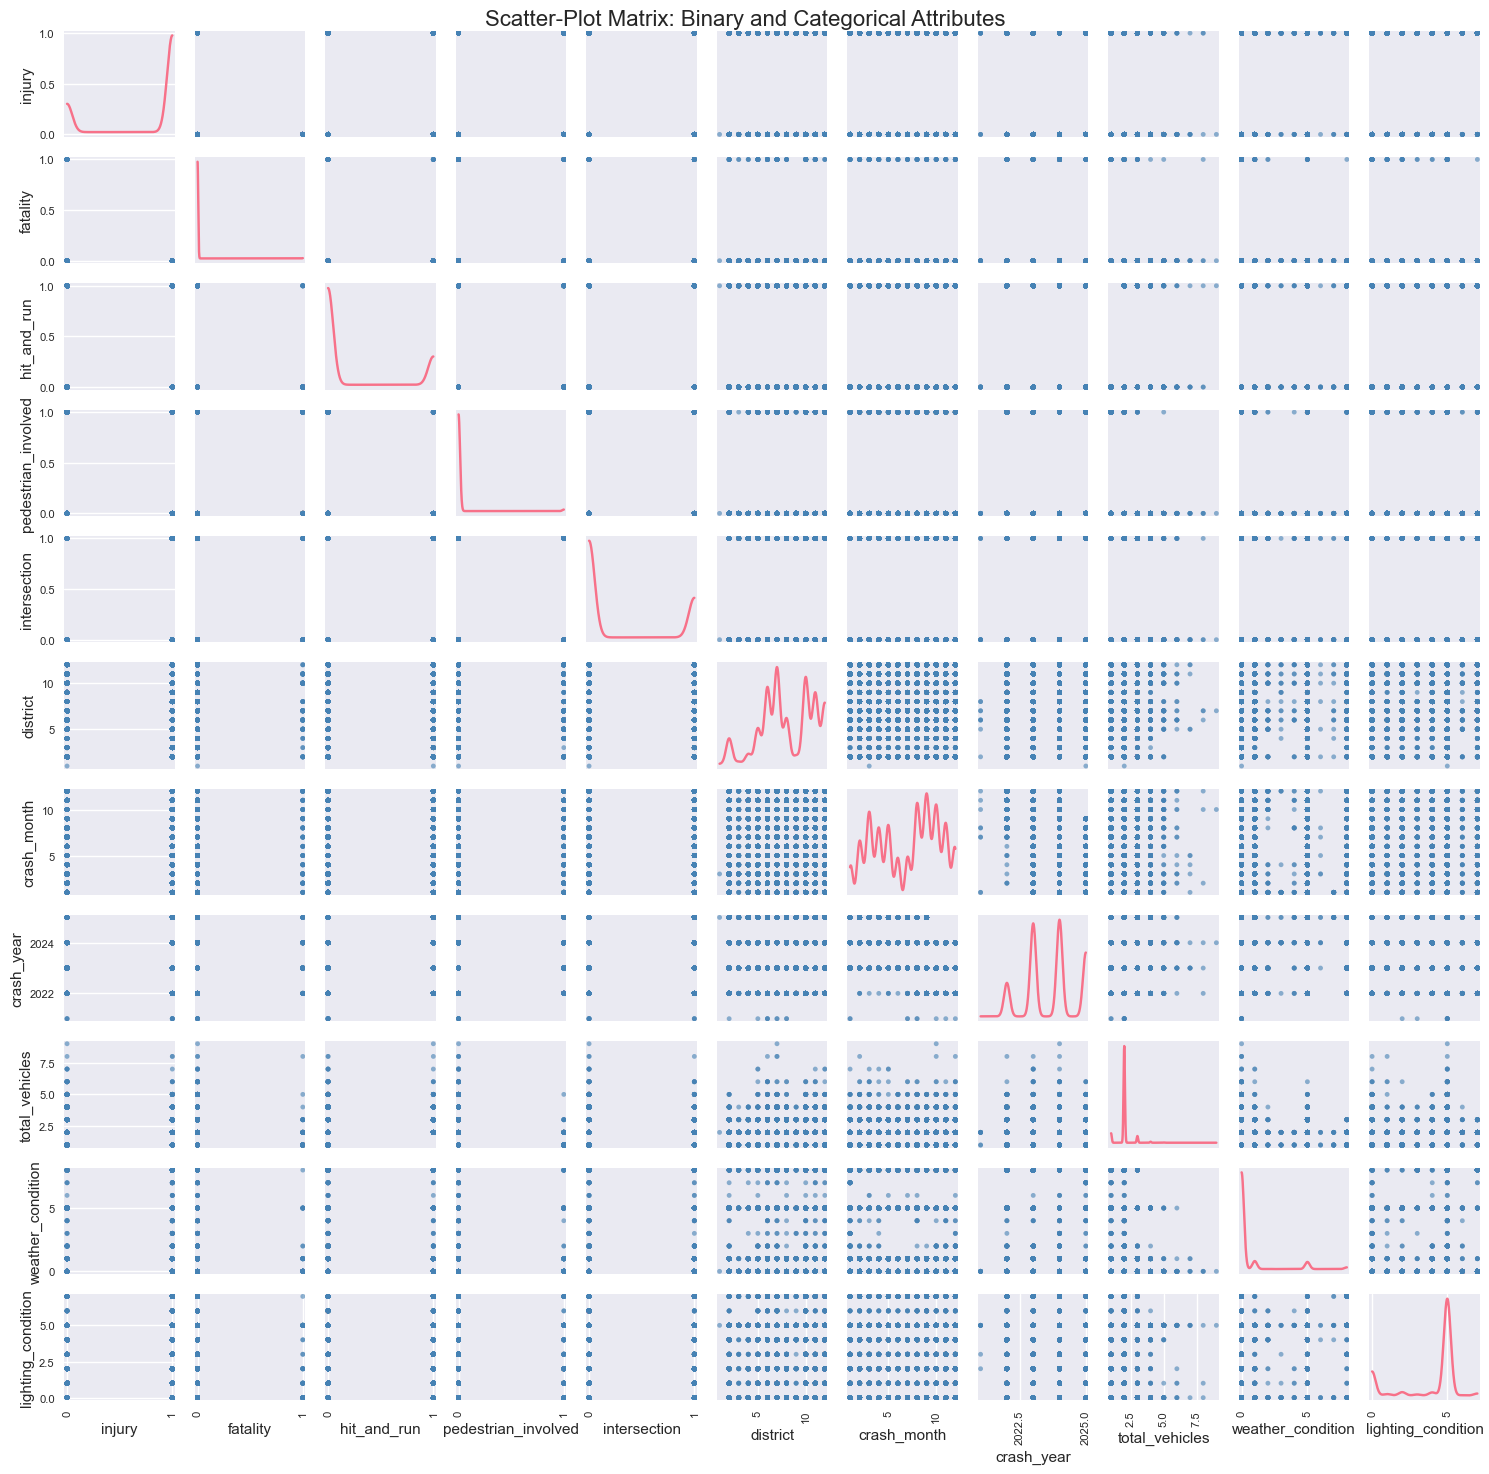

In [26]:
# Create a more focused scatter-plot matrix for binary and categorical attributes
binary_categorical_attrs = [
    'injury', 'fatality', 'hit_and_run', 'pedestrian_involved', 
    'intersection', 'district', 'crash_month', 'crash_year',
    'total_vehicles', 'weather_condition', 'lighting_condition'
]

# Filter to existing attributes
binary_categorical_attrs = [attr for attr in binary_categorical_attrs if attr in df_encoded.columns]

plt.figure(figsize=(15, 15))
pd.plotting.scatter_matrix(df_encoded[binary_categorical_attrs], 
                          alpha=0.6, 
                          figsize=(15, 15),
                          cmap='Blues',
                          c='steelblue',
                          diagonal='kde')
plt.suptitle('Scatter-Plot Matrix: Binary and Categorical Attributes', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


<Figure size 1500x1500 with 0 Axes>

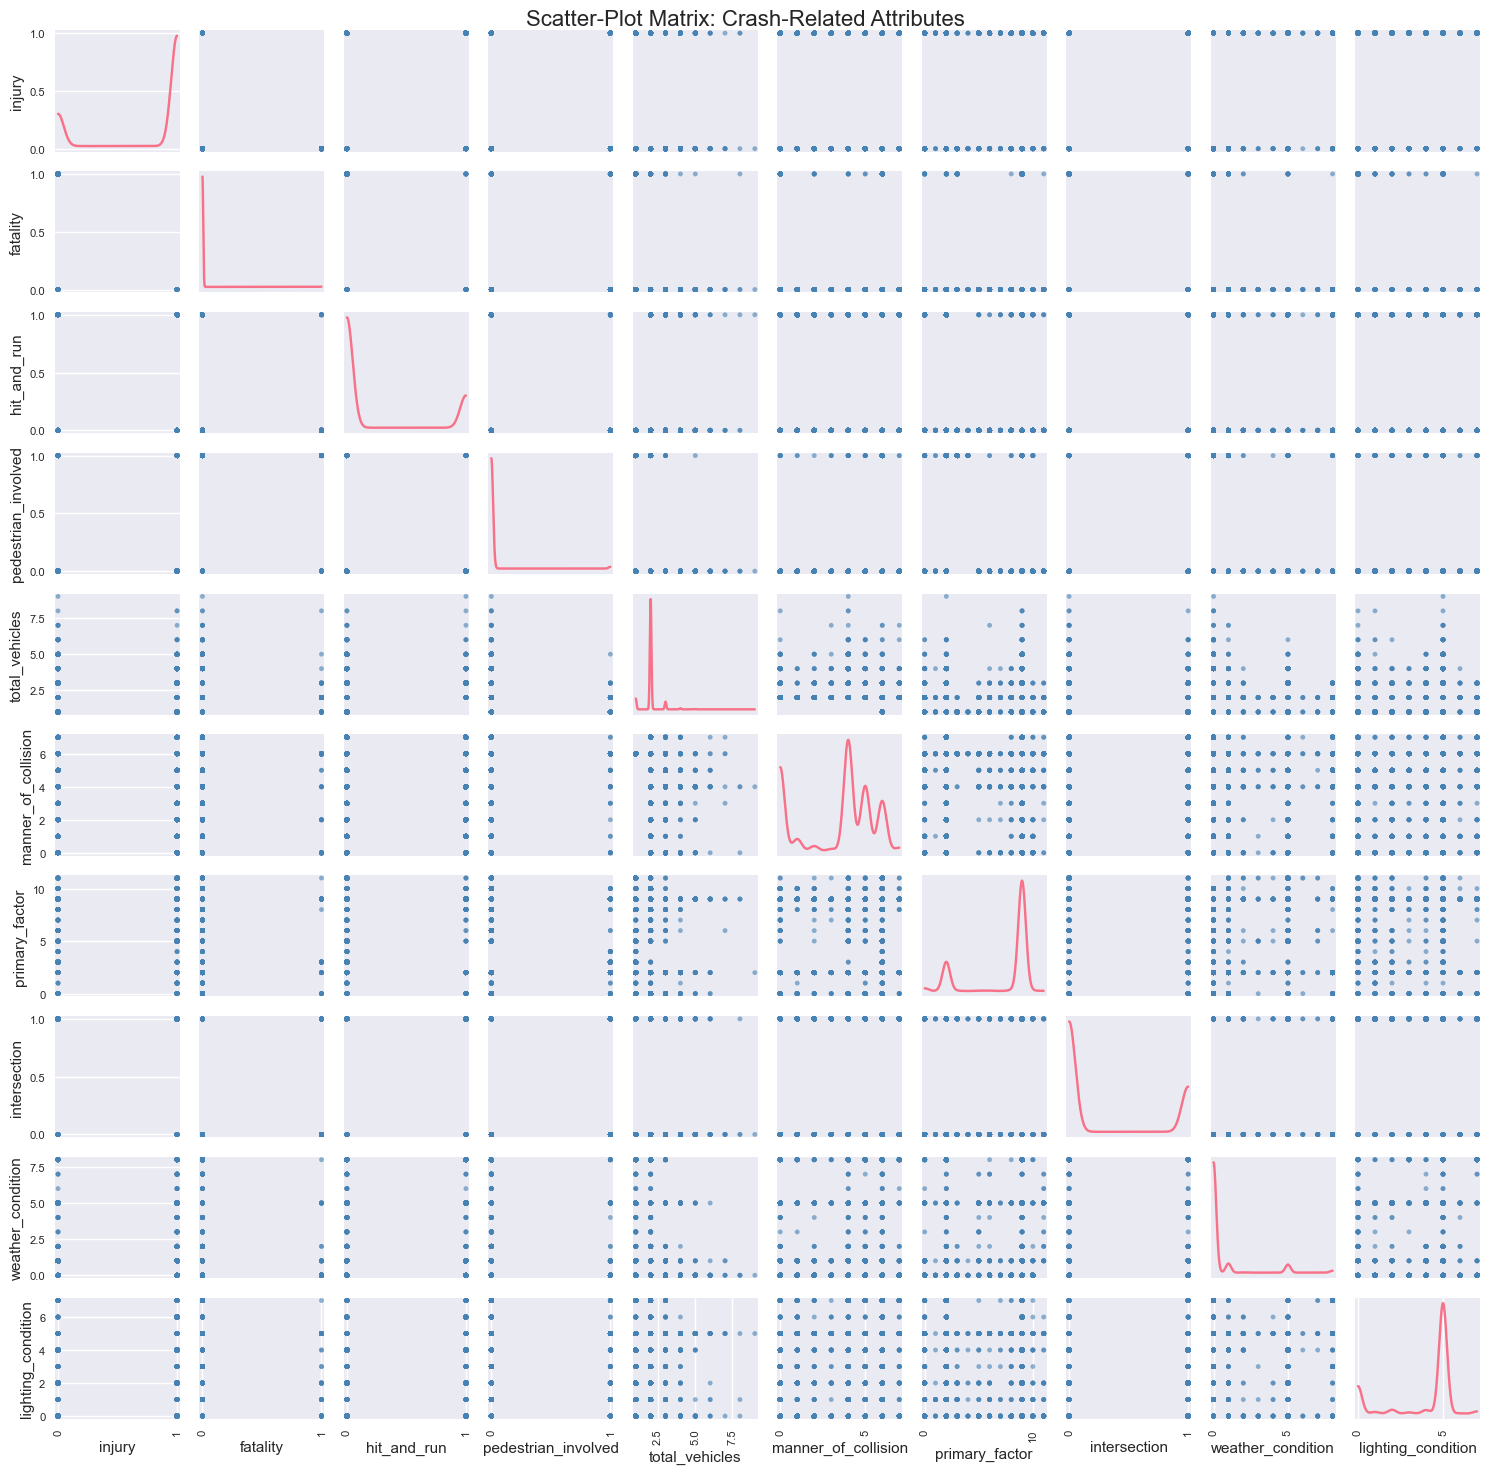

In [25]:
# Create scatter-plot matrix for crash-related attributes
crash_attrs = [
    'injury', 'fatality', 'hit_and_run', 'pedestrian_involved',
    'total_vehicles', 'manner_of_collision', 'primary_factor',
    'intersection', 'weather_condition', 'lighting_condition'
]

# Filter to existing attributes
crash_attrs = [attr for attr in crash_attrs if attr in df_encoded.columns]

plt.figure(figsize=(15, 15))
pd.plotting.scatter_matrix(df_encoded[crash_attrs], 
                          alpha=0.6, 
                          figsize=(15, 15),
                          cmap='Blues',
                          c='steelblue',
                          diagonal='kde')
plt.suptitle('Scatter-Plot Matrix: Crash-Related Attributes', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


## Heatmap Visualization of Correlation Matrix

Create heatmaps to visualize correlations more clearly.


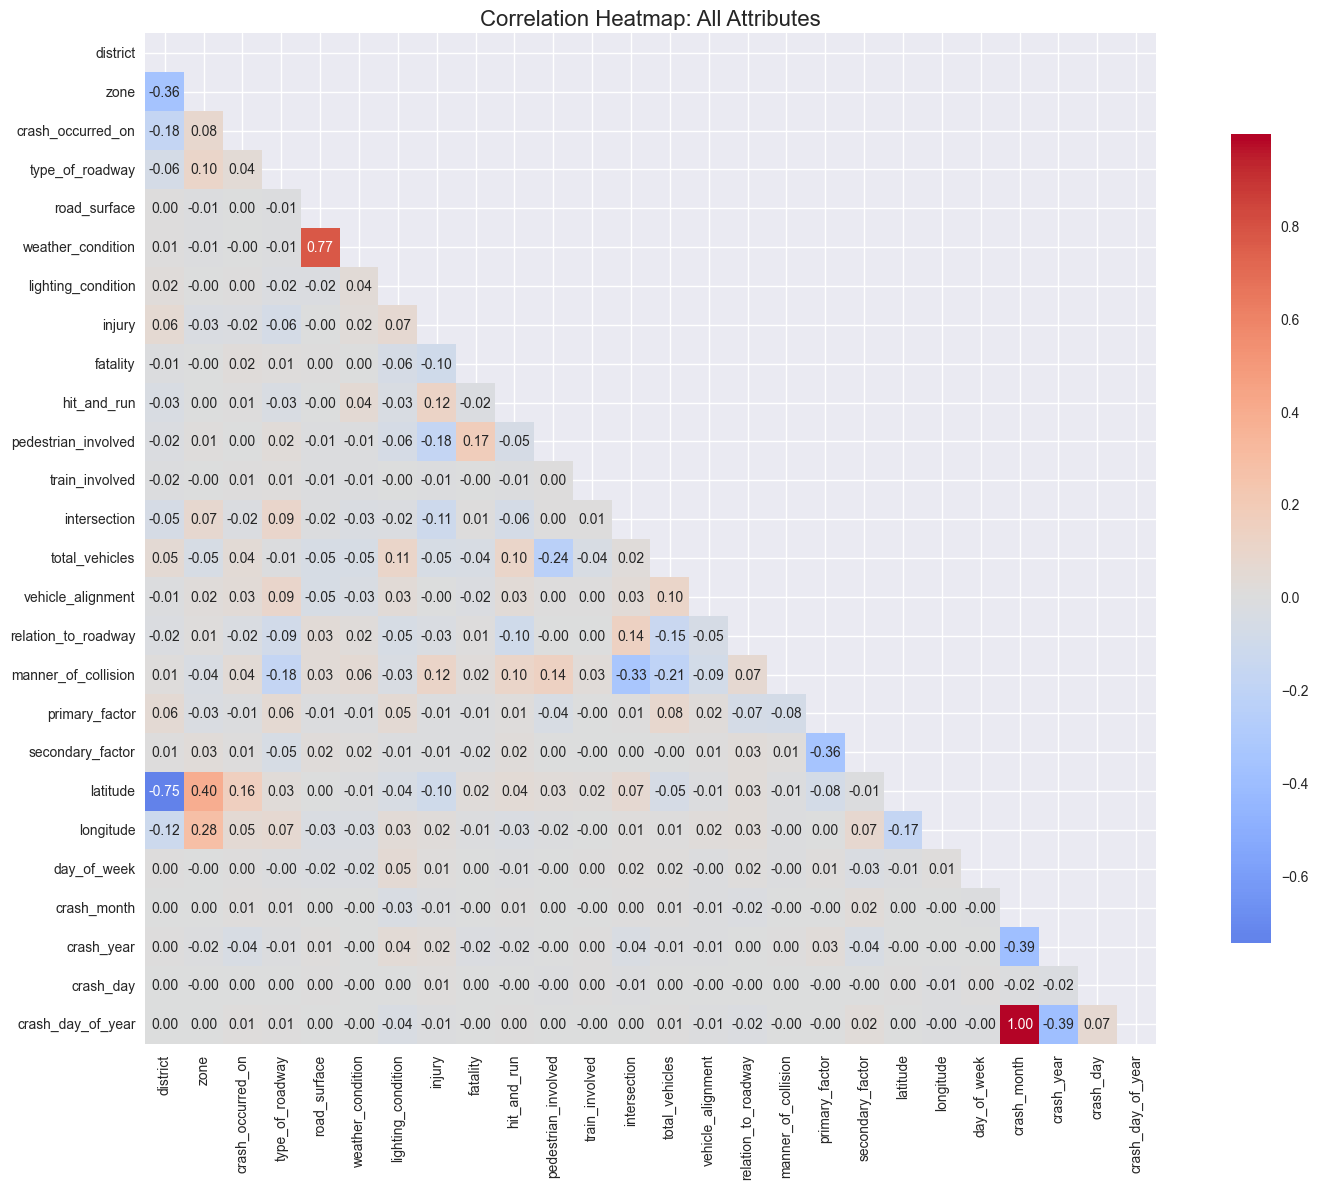

In [12]:
# Create correlation heatmap for all attributes
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap: All Attributes', fontsize=16)
plt.tight_layout()
plt.show()


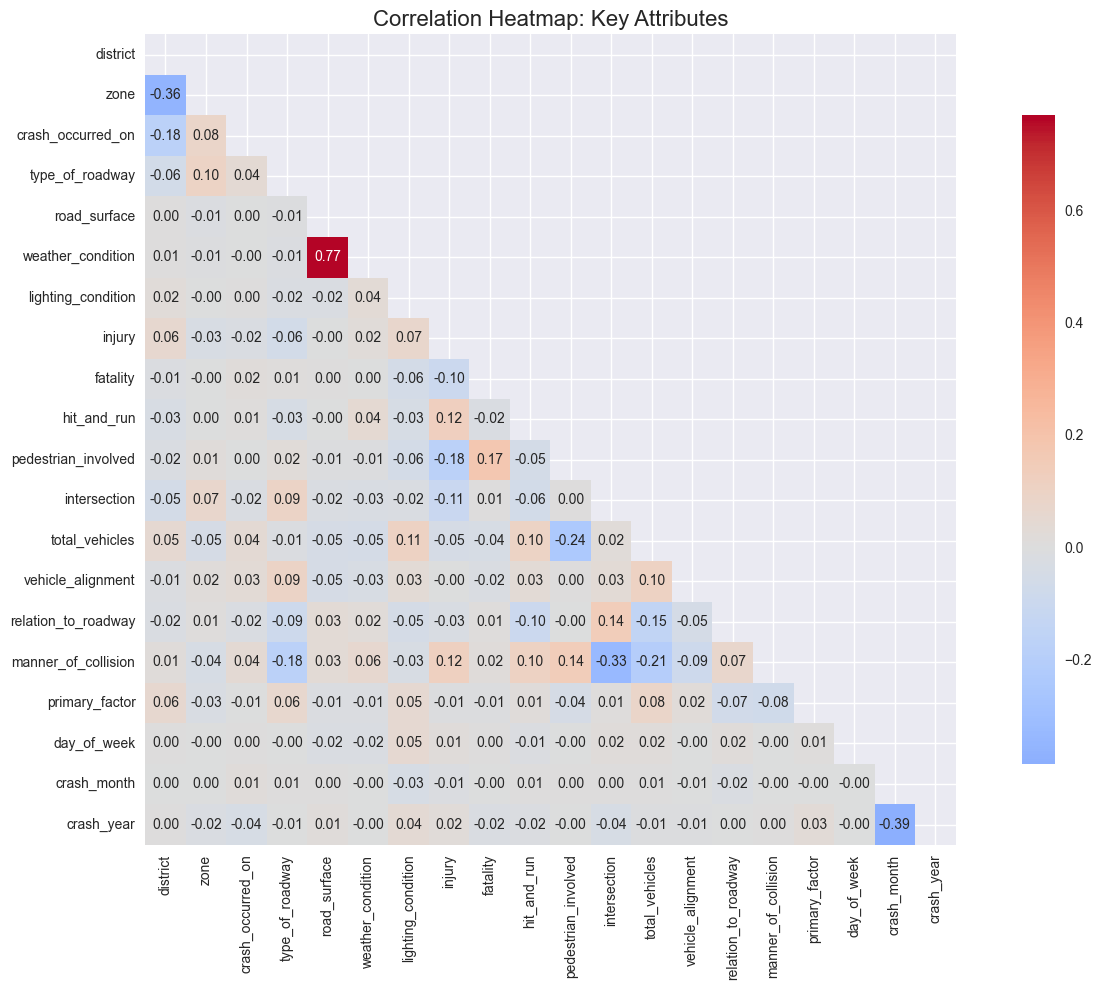

In [13]:
# Create focused correlation heatmap for key attributes
key_corr_matrix = df_encoded[key_attributes].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(key_corr_matrix, dtype=bool))
sns.heatmap(key_corr_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap: Key Attributes', fontsize=16)
plt.tight_layout()
plt.show()


## Statistical Correlation Analysis

Perform statistical tests to identify significant correlations.


In [14]:
# Calculate Pearson correlation coefficients and p-values
def calculate_correlations(df, columns):
    correlations = []
    for i in range(len(columns)):
        for j in range(i+1, len(columns)):
            col1, col2 = columns[i], columns[j]
            
            # Pearson correlation
            pearson_corr, pearson_p = pearsonr(df[col1], df[col2])
            
            # Spearman correlation (for non-linear relationships)
            spearman_corr, spearman_p = spearmanr(df[col1], df[col2])
            
            correlations.append({
                'variable1': col1,
                'variable2': col2,
                'pearson_corr': pearson_corr,
                'pearson_p': pearson_p,
                'spearman_corr': spearman_corr,
                'spearman_p': spearman_p,
                'abs_pearson': abs(pearson_corr),
                'abs_spearman': abs(spearman_corr)
            })
    
    return pd.DataFrame(correlations)

# Calculate correlations for key attributes
correlation_results = calculate_correlations(df_encoded, key_attributes)

print("Correlation Analysis Results:")
print(correlation_results.head(10))


Correlation Analysis Results:
  variable1            variable2  pearson_corr      pearson_p  spearman_corr  \
0  district                 zone     -0.359511   0.000000e+00      -0.318917   
1  district    crash_occurred_on     -0.175983  1.982959e-312      -0.117040   
2  district      type_of_roadway     -0.064037   1.861678e-42      -0.062568   
3  district         road_surface      0.003768   4.221621e-01       0.006744   
4  district    weather_condition      0.005472   2.437187e-01      -0.001998   
5  district   lighting_condition      0.022978   9.800164e-07       0.028699   
6  district               injury      0.059462   7.787833e-37       0.059122   
7  district             fatality     -0.012105   9.914601e-03      -0.013157   
8  district          hit_and_run     -0.033480   9.728038e-13      -0.038011   
9  district  pedestrian_involved     -0.020360   1.439705e-05      -0.021333   

      spearman_p  abs_pearson  abs_spearman  
0   0.000000e+00     0.359511      0.318917

In [15]:
# Find significant correlations (p < 0.05 and |correlation| > 0.1)
significant_correlations = correlation_results[
    (correlation_results['pearson_p'] < 0.05) & 
    (correlation_results['abs_pearson'] > 0.1)
].sort_values('abs_pearson', ascending=False)

print(f"Significant correlations found: {len(significant_correlations)}")
print("\nTop 20 significant correlations:")
print(significant_correlations[['variable1', 'variable2', 'pearson_corr', 'pearson_p']].head(20))


Significant correlations found: 20

Top 20 significant correlations:
               variable1            variable2  pearson_corr      pearson_p
70          road_surface    weather_condition      0.768524   0.000000e+00
189          crash_month           crash_year     -0.385867   0.000000e+00
0               district                 zone     -0.359511   0.000000e+00
157         intersection  manner_of_collision     -0.334145   0.000000e+00
146  pedestrian_involved       total_vehicles     -0.241033   0.000000e+00
164       total_vehicles  manner_of_collision     -0.205784   0.000000e+00
114               injury  pedestrian_involved     -0.177703  1.278662e-318
65       type_of_roadway  manner_of_collision     -0.176524  2.279601e-314
1               district    crash_occurred_on     -0.175983  1.982959e-312
125             fatality  pedestrian_involved      0.173635  4.469597e-304
163       total_vehicles  relation_to_roadway     -0.145300  1.343944e-212
156         intersection  relat

In [16]:
# Find strong correlations (|correlation| > 0.3)
strong_correlations = correlation_results[
    correlation_results['abs_pearson'] > 0.3
].sort_values('abs_pearson', ascending=False)

print(f"Strong correlations found: {len(strong_correlations)}")
print("\nStrong correlations:")
print(strong_correlations[['variable1', 'variable2', 'pearson_corr', 'pearson_p']])


Strong correlations found: 4

Strong correlations:
        variable1            variable2  pearson_corr  pearson_p
70   road_surface    weather_condition      0.768524        0.0
189   crash_month           crash_year     -0.385867        0.0
0        district                 zone     -0.359511        0.0
157  intersection  manner_of_collision     -0.334145        0.0


## Pairwise Scatter Plots for High Correlations

Create detailed scatter plots for the most interesting correlations.


In [28]:
strong_correlations

,variable1,variable2,pearson_corr,pearson_p,spearman_corr,spearman_p,abs_pearson,abs_spearman
70,road_surface,weather_condition,0.768524,0.0,0.737339,0.0,0.768524,0.737339
189,crash_month,crash_year,-0.385867,0.0,-0.370513,0.0,0.385867,0.370513
0,district,zone,-0.359511,0.0,-0.318917,0.0,0.359511,0.318917
157,intersection,manner_of_collision,-0.334145,0.0,-0.307220,0.0,0.334145,0.307220


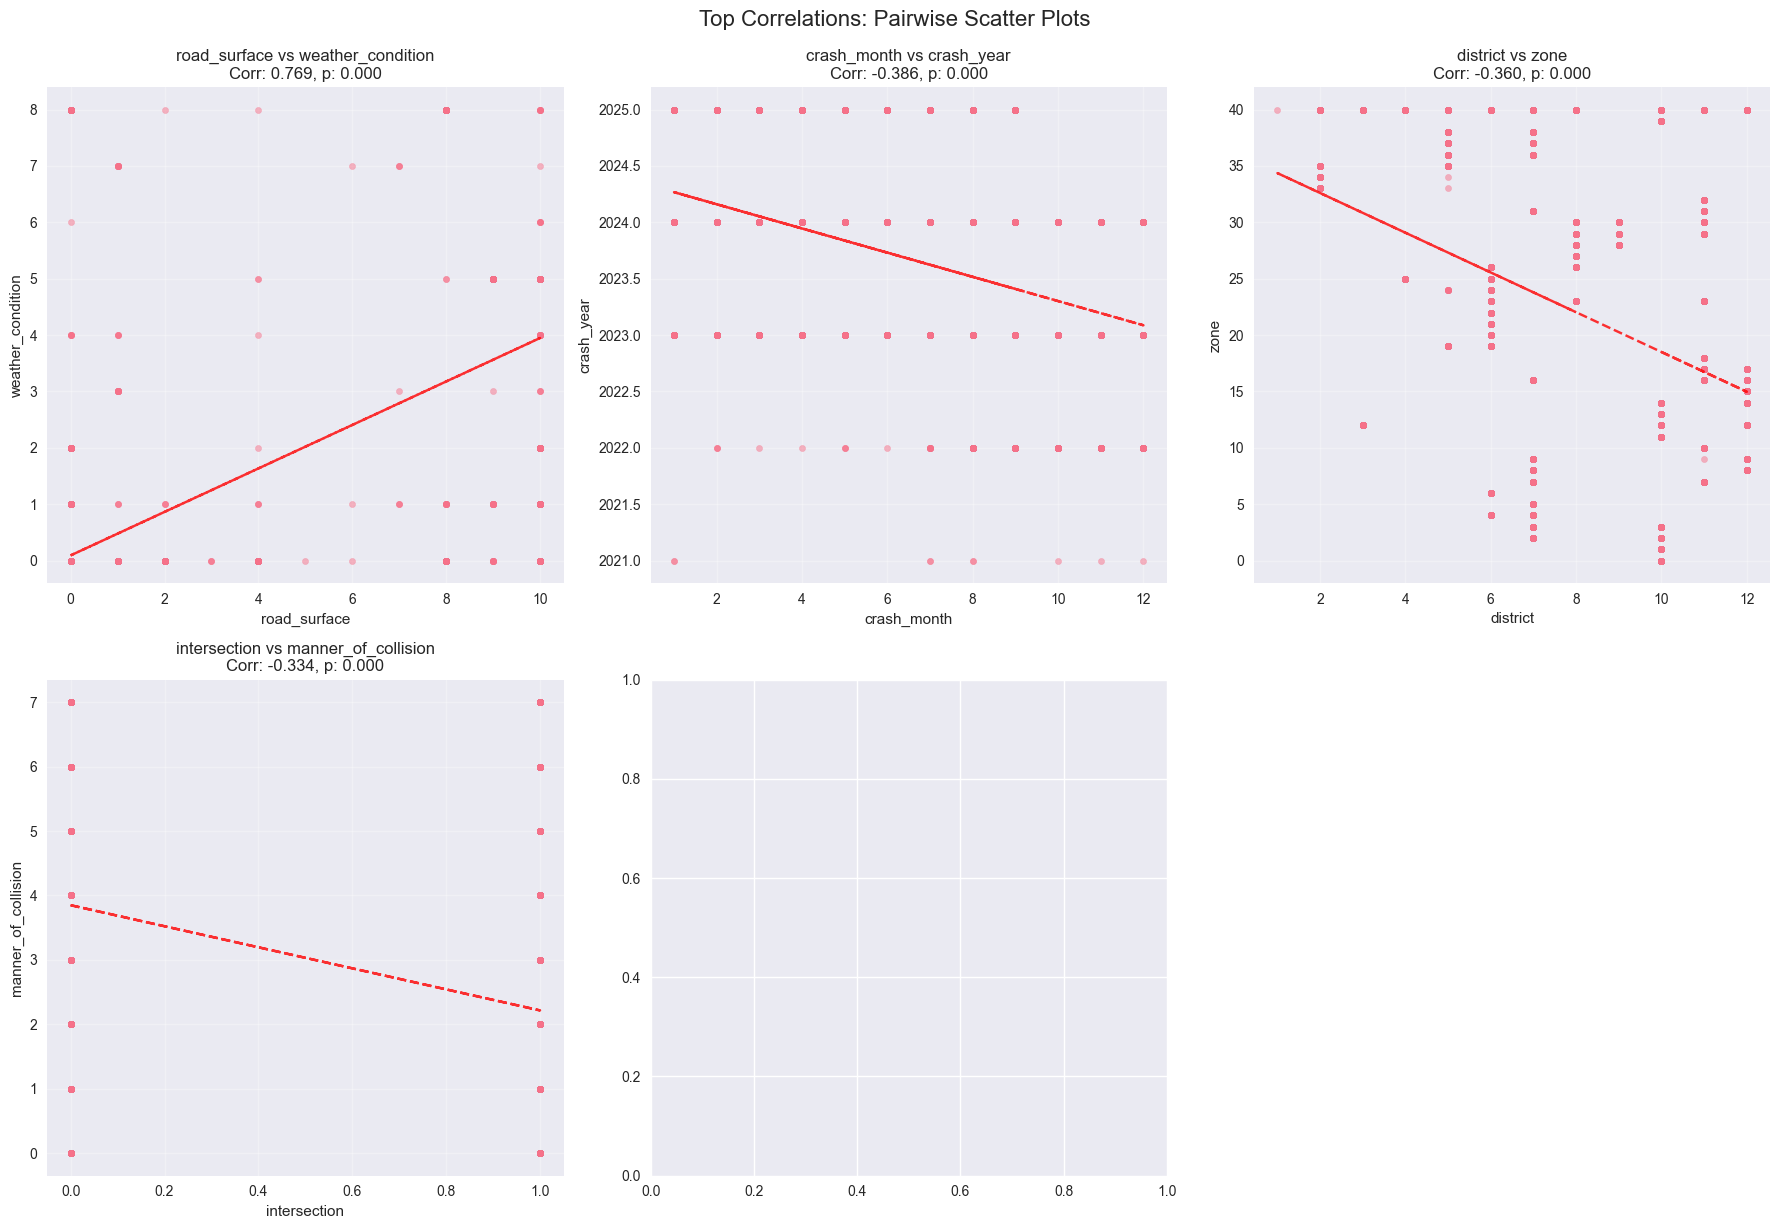

In [ ]:
# Create pairwise scatter plots for top correlations
if len(strong_correlations) > 0:
    top_correlations = strong_correlations.head(6)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    for idx, (_, row) in enumerate(top_correlations.iterrows()):
        if idx < 6:
            ax = axes[idx]
            
            # Create scatter plot
            ax.scatter(df_encoded[row['variable1']], 
                      df_encoded[row['variable2']], 
                      alpha=0.5, s=20)
            
            # Add trend line
            z = np.polyfit(df_encoded[row['variable1']], df_encoded[row['variable2']], 1)
            p = np.poly1d(z)
            ax.plot(df_encoded[row['variable1']], p(df_encoded[row['variable1']]), 
                   "r--", alpha=0.8)
            
            ax.set_xlabel(row['variable1'])
            ax.set_ylabel(row['variable2'])
            ax.set_title(f"{row['variable1']} vs {row['variable2']}\n"
                        f"Corr: {row['pearson_corr']:.3f}, p: {row['pearson_p']:.3f}")
            
            # Add grid
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Top Correlations: Pairwise Scatter Plots', fontsize=16, y=1.02)
    plt.show()
else:
    print("No strong correlations found for detailed scatter plots")


## Summary and Insights

### Key Findings from Correlation Analysis:


In [18]:
# Summary statistics
print("=== CORRELATION ANALYSIS SUMMARY ===")
print(f"Total attributes analyzed: {len(key_attributes)}")
print(f"Total correlation pairs: {len(correlation_results)}")
print(f"Significant correlations (p<0.05, |r|>0.1): {len(significant_correlations)}")
print(f"Strong correlations (|r|>0.3): {len(strong_correlations)}")

print("\n=== TOP 10 STRONGEST CORRELATIONS ===")
if len(strong_correlations) > 0:
    top_10 = strong_correlations.head(10)
    for idx, (_, row) in enumerate(top_10.iterrows(), 1):
        print(f"{idx:2d}. {row['variable1']} ↔ {row['variable2']}: "
              f"r = {row['pearson_corr']:.3f}, p = {row['pearson_p']:.3f}")
else:
    print("No strong correlations found.")

print("\n=== ATTRIBUTE GROUPS WITH HIGHEST CORRELATIONS ===")
if len(significant_correlations) > 0:
    # Group by variable1 to see which attributes have most correlations
    var1_counts = significant_correlations['variable1'].value_counts()
    var2_counts = significant_correlations['variable2'].value_counts()
    
    # Combine counts
    all_vars = pd.concat([var1_counts, var2_counts], axis=1).fillna(0)
    all_vars['total_correlations'] = all_vars.iloc[:, 0] + all_vars.iloc[:, 1]
    all_vars = all_vars.sort_values('total_correlations', ascending=False)
    
    print("Attributes with most significant correlations:")
    print(all_vars.head(10))


=== CORRELATION ANALYSIS SUMMARY ===
Total attributes analyzed: 20
Total correlation pairs: 190
Significant correlations (p<0.05, |r|>0.1): 20
Strong correlations (|r|>0.3): 4

=== TOP 10 STRONGEST CORRELATIONS ===
 1. road_surface ↔ weather_condition: r = 0.769, p = 0.000
 2. crash_month ↔ crash_year: r = -0.386, p = 0.000
 3. district ↔ zone: r = -0.360, p = 0.000
 4. intersection ↔ manner_of_collision: r = -0.334, p = 0.000

=== ATTRIBUTE GROUPS WITH HIGHEST CORRELATIONS ===
Attributes with most significant correlations:
                     count  count  total_correlations
manner_of_collision    0.0    6.0                 6.0
total_vehicles         3.0    2.0                 5.0
injury                 4.0    0.0                 4.0
pedestrian_involved    2.0    2.0                 4.0
intersection           2.0    1.0                 3.0
relation_to_roadway    0.0    2.0                 2.0
district               2.0    0.0                 2.0
type_of_roadway        1.0    1.0     

## Conclusions

The scatter-plot matrix analysis reveals:

1. **Correlation Patterns**: The analysis shows various correlation patterns between discretized attributes in the traffic crash dataset.

2. **Key Relationships**: The strongest correlations help identify which attributes tend to co-occur or are related in traffic incidents.

3. **Statistical Significance**: The p-values indicate which correlations are statistically significant versus those that might occur by chance.

4. **Visual Insights**: The scatter plots provide visual confirmation of linear and non-linear relationships between attribute pairs.

This analysis can be used for:
- Feature selection in machine learning models
- Understanding causal relationships in traffic safety
- Identifying risk factors that tend to co-occur
- Data quality assessment and validation
